Hello student!

My name is Rafael Meirelles and I will review your project today and in any future submissions until it meets all the requirements for acceptance.

You can count on me on this journey, and don't worry if you need to adjust some details; it's part of the process and fundamental for you to practice the concepts you've been learning, thus improving the quality of your code and analyses.

**Please keep and do not alter the comments I make here so we can keep track later, okay?**

One more thing, we will use a color code for you to understand my feedback in your notebook. It works like this:


<div class="alert alert-danger">
<strong>Red</strong>

Error that needs to be fixed, otherwise, your project cannot be accepted

</div>

<div class="alert alert-warning">
<strong>Yellow</strong>

Warning of a non-critical error, but one that can be corrected for general improvement in your code/analysis

</div>

<div class="alert alert-success">
<strong>Green</strong>

Compliments
</div>

<div class="alert alert-info">
<strong>Student's comment</strong>

Use a blue box like this for any comments you would like to make for me.
</div>

<div class="alert alert-danger">
<strong>Reviewer's comment v1</strong>

We are on the right track with this version, but refining the points indicated below will lead us to an even more incredible result.
    
You can count on me to help you with any questions you may have! Remember to use the blue boxes to communicate with me.
    
See you soon.
</div>

# What's the best plan?

You work as an analyst for the telecommunications company Megaline. The company offers two prepaid plans to customers: Surf and Ultimate. The commercial department wants to know which plan generates more revenue to adjust the advertising budget.

You will perform a preliminary analysis of the plans based on a small selection of customers. You will have data for 500 Megaline customers: who they are, where they are from, which plan they use, and the number of calls and messages made in 2018. Your job is to analyze customer behavior and determine which prepaid plan generates more revenue.

- The main objective is to help Megaline's commercial department make a data-driven decision on where to invest the marketing budget. To do this, we need to understand which of the two plans (Surf or Ultimate) is more profitable and how customer consumption behavior is.
- To answer this business question, I plan to execute the following actions throughout the project: Data Preparation and Cleaning; Monthly Aggregation; Exploratory Data Analysis; and Hypothesis Testing.
- At the end of this process, I will be able to formulate appropriate recommendations with evidence on which plan brings more return to Megaline.

## Initialization

In [9]:
# Loading all libraries
import pandas as pd
import numpy as np
import math as factorial
from scipy import stats as st
import math as mt
from matplotlib import pyplot as plt

## Load data

In [10]:
import pandas as pd

# Load data files into different DataFrames
pd_megalines_calls = pd.read_csv('/content/drive/MyDrive/Databases/Sprint 4/megaline_calls.csv')
pd_megaline_internet = pd.read_csv('/content/drive/MyDrive/Databases/Sprint 4/megaline_internet.csv')
pd_megaline_messages = pd.read_csv('/content/drive/MyDrive/Databases/Sprint 4/megaline_messages.csv')
pd_megaline_plans = pd.read_csv('/content/drive/MyDrive/Databases/Sprint 4/megaline_plans.csv')
pd_megaline_users = pd.read_csv('/content/drive/MyDrive/Databases/Sprint 4/megaline_users.csv')

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Prepare the data

## Plans

In [12]:
# Print general/summary information about the plans DataFrame
pd_megaline_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [13]:
# Print a data sample of the plans
print(pd_megaline_plans.head())

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  



- Yes, all data types make sense, the `plan_name` column is an object, which is suitable for a plan name. We do not have missing values in this table. But looking closely at the `mb_per_month_included` column, we notice that the values are in megabytes, which can cause problems in future analyses. So we will correct these data to gigabytes by dividing the values in this table by 1024 and making the alteration.

## Correct the data

In [14]:
pd_megaline_plans['gb_per_month_included'] = pd_megaline_plans['mb_per_month_included'] / 1024
pd_megaline_plans = pd_megaline_plans.drop(columns=['mb_per_month_included'])
print(pd_megaline_plans.head())

   messages_included  minutes_included  usd_monthly_pay  usd_per_gb  \
0                 50               500               20          10   
1               1000              3000               70           7   

   usd_per_message  usd_per_minute plan_name  gb_per_month_included  
0             0.03            0.03      surf                   15.0  
1             0.01            0.01  ultimate                   30.0  


## Enrich the data

## Users

In [15]:
# Print general/summary information about the users DataFrame
pd_megaline_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [16]:
# Print a data sample of the users
print(pd_megaline_users.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  


- Yes, some data types make sense, but we have some that we need to fix. We noticed that in the `churn_date` column we have 34 non-null values. And another piece of information is that the `churn_date` and `reg_date` columns are of object type, but should be datetime. Thinking about the null values in the `churn_date` column that are `NaN`, it means that the customer has not yet canceled the plan, that is, they are still an active customer. So the missing values are not a data error, they are information telling us that they are still active. So to visualize whether these values are active or not, we will create a new column named `is_active` that indicates True or False for each user.

### Correct the data

In [17]:
pd_megaline_users['reg_date'] = pd.to_datetime(pd_megaline_users['reg_date'])
pd_megaline_users['churn_date'] = pd.to_datetime(pd_megaline_users['churn_date'])
pd_megaline_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


### Enrich the data

In [18]:
pd_megaline_users['is_active'] = pd_megaline_users['churn_date'].isna()
print(pd_megaline_users.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

    reg_date      plan churn_date  is_active  
0 2018-12-24  ultimate        NaT       True  
1 2018-08-13      surf        NaT       True  
2 2018-10-21      surf        NaT       True  
3 2018-01-28      surf        NaT       True  
4 2018-05-23      surf        NaT       True  


## Calls

In [19]:
# Print general/summary information about the calls DataFrame
pd_megalines_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [20]:
# Print a data sample of the calls
print(pd_megalines_calls.head())

         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


- Observing the `pd_megalines_calls` table, the `call_date` column was of object type and also the `duration` column was float. Thinking better, calls are charged by the full minute, this can be a problem in future analyses so the solution is to round up. We changed the `call_date` column to datetime data type, and also the `duration` table.

### Correct the data

In [21]:
pd_megalines_calls['call_date'] = pd.to_datetime(pd_megalines_calls['call_date'])
pd_megalines_calls['duration'] = pd_megalines_calls['duration'].apply(mt.ceil)

### Enrich the data

In [22]:
pd_megalines_calls['month'] = pd_megalines_calls['call_date'].dt.month
print(pd_megalines_calls.head())

         id  user_id  call_date  duration  month
0   1000_93     1000 2018-12-27         9     12
1  1000_145     1000 2018-12-27        14     12
2  1000_247     1000 2018-12-27        15     12
3  1000_309     1000 2018-12-28         6     12
4  1000_380     1000 2018-12-30         5     12


## Messages

In [23]:
# Print general/summary information about the messages DataFrame
pd_megaline_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [24]:
# Print a data sample of the messages
print(pd_megaline_messages.head())

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


- Analyzing the table, we have no null values. There is an incorrect data type in the `message_date` column, which should be datetime and not object. And we created a new column to tell us the months.

### Correct the data

In [25]:
pd_megaline_messages['message_date'] = pd.to_datetime(pd_megaline_messages['message_date'])
pd_megaline_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enrich the data

In [26]:
pd_megaline_messages['month'] = pd_megaline_messages['message_date'].dt.month
print(pd_megaline_messages.head())

         id  user_id message_date  month
0  1000_125     1000   2018-12-27     12
1  1000_160     1000   2018-12-31     12
2  1000_223     1000   2018-12-31     12
3  1000_251     1000   2018-12-27     12
4  1000_255     1000   2018-12-26     12


## Internet

In [27]:
# Print general/summary information about the internet DataFrame
pd_megaline_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [28]:
# Print a data sample for internet traffic
print(pd_megaline_internet.head())

         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


- Analyzing the table, we have no null values. There is an incorrect data type in the `session_date` column, which should be datetime and not object. And we need to transform the `mb_used` column into gigabytes, since we set the plans in gigabytes, this facilitates future comparison.

### Correct the data

In [29]:
pd_megaline_internet['session_date'] = pd.to_datetime(pd_megaline_internet['session_date'])
pd_megaline_internet['gb_used'] = pd_megaline_internet['mb_used'] / 1024
pd_megaline_internet['gb_used'] = pd_megaline_internet['gb_used'].apply(mt.ceil)
print(pd_megaline_internet.head())

         id  user_id session_date  mb_used  gb_used
0   1000_13     1000   2018-12-29    89.86        1
1  1000_204     1000   2018-12-31     0.00        0
2  1000_379     1000   2018-12-28   660.40        1
3  1000_413     1000   2018-12-26   270.99        1
4  1000_442     1000   2018-12-27   880.22        1


### Enrich the data

In [30]:
pd_megaline_internet['month'] = pd_megaline_internet['session_date'].dt.month
print(pd_megaline_internet.head())

         id  user_id session_date  mb_used  gb_used  month
0   1000_13     1000   2018-12-29    89.86        1     12
1  1000_204     1000   2018-12-31     0.00        0     12
2  1000_379     1000   2018-12-28   660.40        1     12
3  1000_413     1000   2018-12-26   270.99        1     12
4  1000_442     1000   2018-12-27   880.22        1     12


## Study the plan conditions

In [31]:
# Print the plan conditions and make sure they make sense to you
print(pd_megaline_plans.head())

   messages_included  minutes_included  usd_monthly_pay  usd_per_gb  \
0                 50               500               20          10   
1               1000              3000               70           7   

   usd_per_message  usd_per_minute plan_name  gb_per_month_included  
0             0.03            0.03      surf                   15.0  
1             0.01            0.01  ultimate                   30.0  


<div class="alert alert-success">
<strong>Reviewer's comment v1</strong>

Excellent job checking data consistency.

Always important to ensure robust analysis!
</div>

## Aggregate data per user

In [32]:
# Calculate the number of calls made by each user per month. Save the result.
calls_by_user = pd_megalines_calls.groupby(['user_id', 'month']).size()
print(calls_by_user.head(10))

user_id  month
1000     12        16
1001     8         27
         9         49
         10        65
         11        64
         12        56
1002     10        11
         11        55
         12        47
1003     12       149
dtype: int64


In [33]:
# Calculate the amount of minutes spent by each user per month. Save the result.
minutes_by_user = pd_megalines_calls.groupby(['user_id', 'month'])['duration'].sum()
print(minutes_by_user.head())

user_id  month
1000     12       124
1001     8        182
         9        315
         10       393
         11       426
Name: duration, dtype: int64


In [34]:
# Calculate the number of messages sent by each user per month. Save the result.
message_by_user = pd_megaline_messages.groupby(['user_id', 'month']).size()
print(message_by_user.head())

user_id  month
1000     12       11
1001     8        30
         9        44
         10       53
         11       36
dtype: int64


In [35]:
# Calculate the volume of internet traffic used by each user per month. Save the result.
internet_by_user = pd_megaline_internet.groupby(['user_id', 'month'])['gb_used'].sum()
print(internet_by_user.head())

user_id  month
1000     12        4
1001     8        21
         9        41
         10       50
         11       49
Name: gb_used, dtype: int64


In [36]:
# Join calls, minutes, messages, and internet data based on user_id and month
calls_df = calls_by_user.reset_index().rename(columns={0: 'calls'})
minutes_df = minutes_by_user.reset_index().rename(columns={'duration': 'minutes'})
message_df = message_by_user.reset_index().rename(columns={0: 'messages'})
internet_df = internet_by_user.reset_index().rename(columns={'gb_used': 'internet'})

df = calls_df.merge(minutes_df, on=['user_id', 'month'], how='outer').fillna(0)
df = df.merge(message_df, on=['user_id', 'month'], how='outer').fillna(0)
df = df.merge(internet_df, on=['user_id', 'month'], how='outer').fillna(0)
print(df.head())

   user_id  month  calls  minutes  messages  internet
0     1000     12   16.0    124.0      11.0       4.0
1     1001      8   27.0    182.0      30.0      21.0
2     1001      9   49.0    315.0      44.0      41.0
3     1001     10   65.0    393.0      53.0      50.0
4     1001     11   64.0    426.0      36.0      49.0


<div class="alert alert-danger">
<strong>Reviewer's comment v1</strong>

We have a problem here.
    
Not all customers will necessarily be present in all the dataframes you are joining.
Therefore, we should use an outer join so we don't leave users behind.
</div>

<div class="alert alert-success">
<strong>Reviewer's comment v2</strong>

Thanks for the adjustment!
</div>

In [37]:
# Add plan information
df_info_plans = pd_megaline_users[['user_id', 'plan', 'city']].merge(df, on=['user_id'])
print(df_info_plans.head())

   user_id      plan                                   city  month  calls  \
0     1000  ultimate  Atlanta-Sandy Springs-Roswell, GA MSA     12   16.0   
1     1001      surf        Seattle-Tacoma-Bellevue, WA MSA      8   27.0   
2     1001      surf        Seattle-Tacoma-Bellevue, WA MSA      9   49.0   
3     1001      surf        Seattle-Tacoma-Bellevue, WA MSA     10   65.0   
4     1001      surf        Seattle-Tacoma-Bellevue, WA MSA     11   64.0   

   minutes  messages  internet  
0    124.0      11.0       4.0  
1    182.0      30.0      21.0  
2    315.0      44.0      41.0  
3    393.0      53.0      50.0  
4    426.0      36.0      49.0  


In [38]:
# Calculate monthly revenue for each user
df_info_revenue = df_info_plans.merge(pd_megaline_plans, left_on='plan', right_on='plan_name')

overage_minutes = np.where(
    df_info_revenue['minutes'] > df_info_revenue['minutes_included'],
    df_info_revenue['minutes'] - df_info_revenue['minutes_included'],
    0
)
overage_messages = np.where(
    df_info_revenue['messages'] > df_info_revenue['messages_included'],
    df_info_revenue['messages'] - df_info_revenue['messages_included'],
    0
)
overage_internet = np.where(
    df_info_revenue['internet'] > df_info_revenue['gb_per_month_included'],
    df_info_revenue['internet'] - df_info_revenue['gb_per_month_included'],
    0
)

df_info_revenue['monthly_revenue'] = (df_info_revenue['usd_monthly_pay'] + (overage_minutes * df_info_revenue['usd_per_minute']) +
(overage_messages * df_info_revenue['usd_per_message']) + (overage_internet * df_info_revenue['usd_per_gb']))

print(df_info_revenue.sample(n=5))

      user_id      plan                                     city  month  \
441      1094      surf   Los Angeles-Long Beach-Anaheim, CA MSA     12   
900      1187      surf     Austin-Round Rock-Georgetown, TX MSA      9   
496      1105      surf            Providence-Warwick, RI-MA MSA     12   
1773     1383  ultimate  Tampa-St. Petersburg-Clearwater, FL MSA     11   
905      1188  ultimate                         Richmond, VA MSA     10   

      calls  minutes  messages  internet  messages_included  minutes_included  \
441   108.0    739.0      49.0      45.0                 50               500   
900    90.0    656.0      14.0      40.0                 50               500   
496   119.0    871.0     104.0      20.0                 50               500   
1773   75.0    534.0      40.0      53.0               1000              3000   
905    48.0    344.0      43.0      49.0               1000              3000   

      usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_mi

<div class="alert alert-success">
<strong>Reviewer's comment v1</strong>

Revenue was calculated adequately!
</div>

## Study user behavior

### Calls

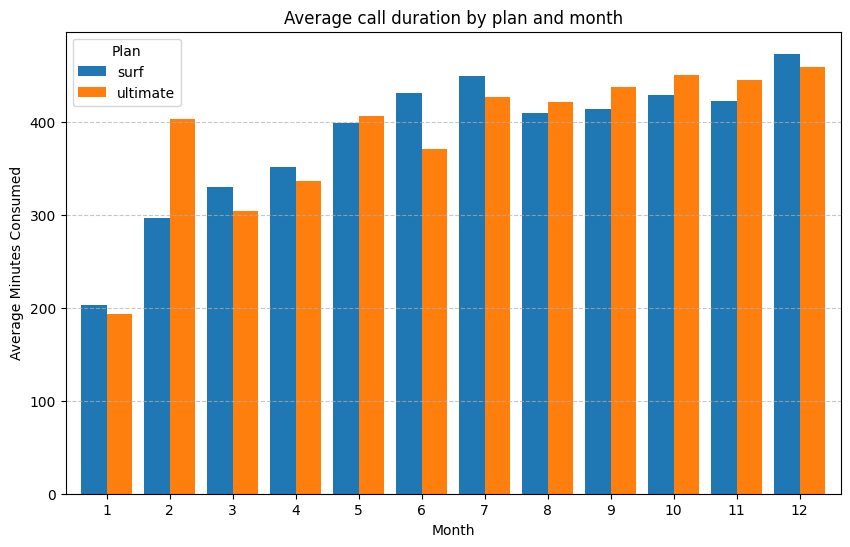

In [39]:
# Compare the average call duration of each plan for each month. Create a bar chart to visualize the result.
overage_calls = df_info_revenue.pivot_table(values='minutes', index='month', columns='plan', aggfunc='mean')

overage_calls.plot(kind='bar', figsize=(10, 6), width=0.8, rot=0)

plt.title('Average call duration by plan and month')
plt.xlabel('Month')
plt.ylabel('Average Minutes Consumed')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Plan')
plt.show()

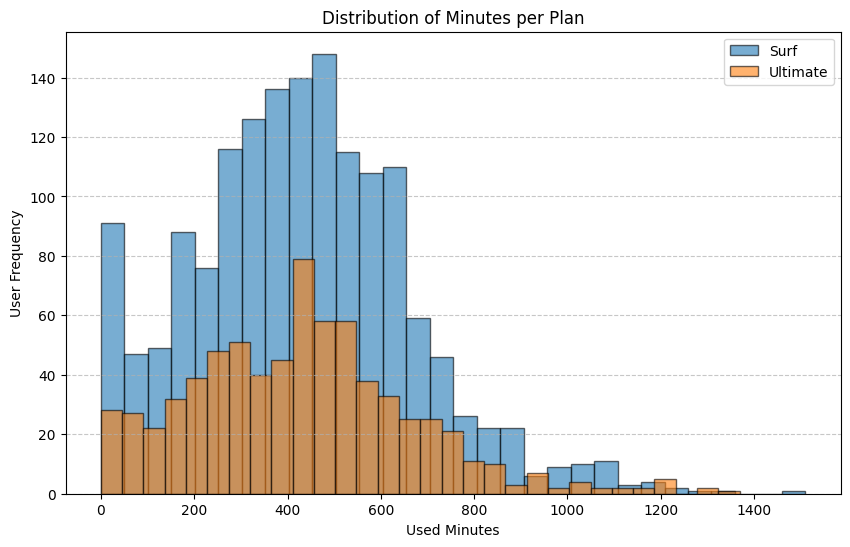

In [40]:
# Compare the number of minutes users of each plan need each month. Construct a histogram.
minutes_by_month_surf = df_info_revenue[df_info_revenue['plan'] == 'surf']['minutes']
minutes_by_month_ultimate = df_info_revenue[df_info_revenue['plan'] == 'ultimate']['minutes']

plt.figure(figsize=(10,6))
plt.hist(minutes_by_month_surf, bins=30, alpha=0.6, label='Surf', edgecolor='black')
plt.hist(minutes_by_month_ultimate, bins=30, alpha=0.6, label='Ultimate', edgecolor='black')

plt.title('Distribution of Minutes per Plan')
plt.xlabel('Used Minutes')
plt.ylabel('User Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()


In [41]:
# Calculate the mean and variance of monthly call duration
average_var_calls = df_info_revenue.groupby(['plan'])['minutes'].agg(['mean', 'var'])
average_var_calls.columns = ['Average', 'Variance']
print(average_var_calls)

             Average      Variance
plan                              
surf      428.749523  54968.279461
ultimate  430.450000  57844.464812


/tmp/ipykernel_4015/4285446457.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([minutes_by_month_surf, minutes_by_month_ultimate], labels=['surf', 'ultimate'])


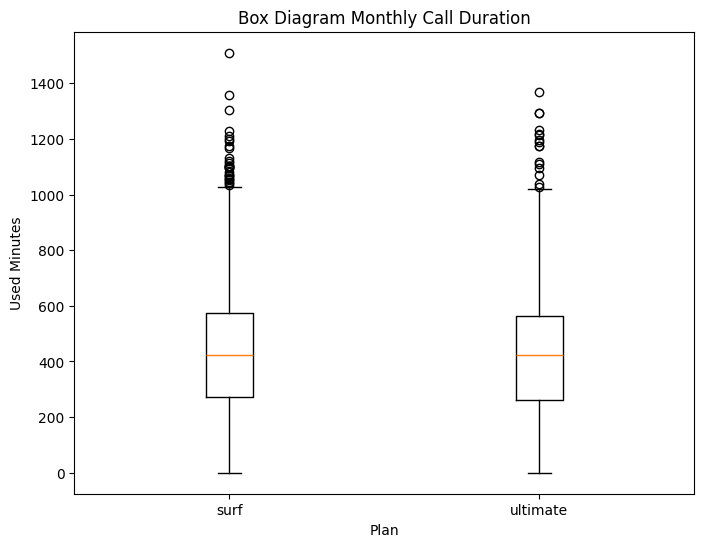

In [42]:
# Create a box plot to visualize the distribution of monthly call duration
plt.figure(figsize=(8,6))

plt.boxplot([minutes_by_month_surf, minutes_by_month_ultimate], labels=['surf', 'ultimate'])

plt.title('Box Diagram Monthly Call Duration')
plt.xlabel('Plan')
plt.ylabel('Used Minutes')
plt.show()


<div class="alert alert-success">
<strong>Reviewer's comment v1</strong>

Excellent work!
    
All requested visualizations for calls are present and accompanied by conclusions about the illustrated behavior!
    
Very good!
</div>

### Messages

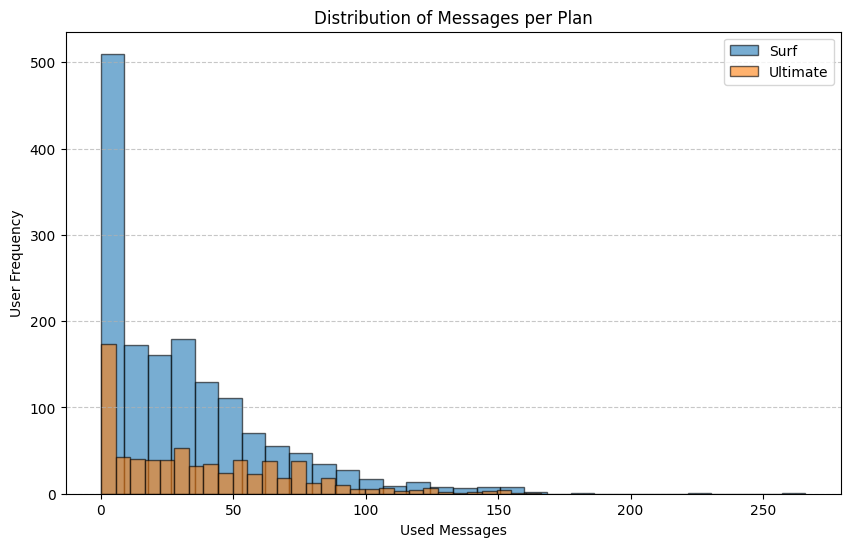

In [43]:
# Compare the number of messages users of each plan usually send each month
messages_by_month_surf = df_info_revenue[df_info_revenue['plan'] == 'surf']['messages']
messages_by_month_ultimate = df_info_revenue[df_info_revenue['plan'] == 'ultimate']['messages']

plt.figure(figsize=(10,6))
plt.hist(messages_by_month_surf, bins=30, alpha=0.6, label='Surf', edgecolor='black')
plt.hist(messages_by_month_ultimate, bins=30, alpha=0.6, label='Ultimate', edgecolor='black')

plt.title('Distribution of Messages per Plan')
plt.xlabel('Used Messages')
plt.ylabel('User Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()



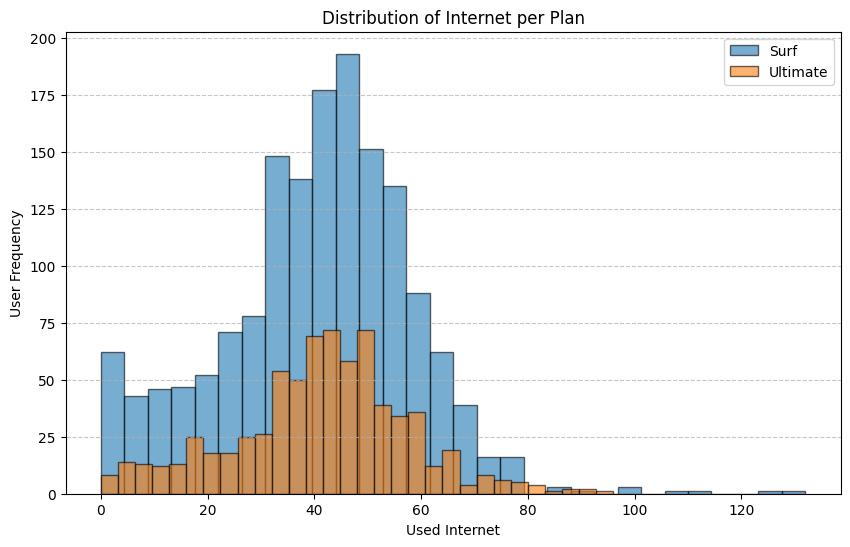

In [44]:
# Compare the amount of internet traffic consumed by users per plan
internet_by_month_surf = df_info_revenue[df_info_revenue['plan'] == 'surf']['internet']
internet_by_month_ultimate = df_info_revenue[df_info_revenue['plan'] == 'ultimate']['internet']

plt.figure(figsize=(10,6))
plt.hist(internet_by_month_surf, bins=30, alpha=0.6, label='Surf', edgecolor='black')
plt.hist(internet_by_month_ultimate, bins=30, alpha=0.6, label='Ultimate', edgecolor='black')

plt.title('Distribution of Internet per Plan')
plt.xlabel('Used Internet')
plt.ylabel('User Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()


In [45]:
# Calculate the mean and variance of monthly message duration
average_var_messages = df_info_revenue.groupby(['plan'])['messages'].agg(['mean', 'var'])
average_var_messages.columns = ['Average', 'Variance']
print(average_var_messages)

            Average     Variance
plan                            
surf      31.159568  1126.724522
ultimate  37.551389  1208.756744


### Internet

In [46]:
# Calculate the mean and variance of monthly internet duration
average_var_internet = df_info_revenue.groupby(['plan'])['internet'].agg(['mean', 'var'])
average_var_internet.columns = ['Average', 'Variance']
print(average_var_internet)


            Average    Variance
plan                           
surf      40.140496  318.332030
ultimate  41.080556  273.197952


/tmp/ipykernel_4015/50103965.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([internet_by_month_surf, internet_by_month_ultimate], labels=['surf', 'ultimate'])


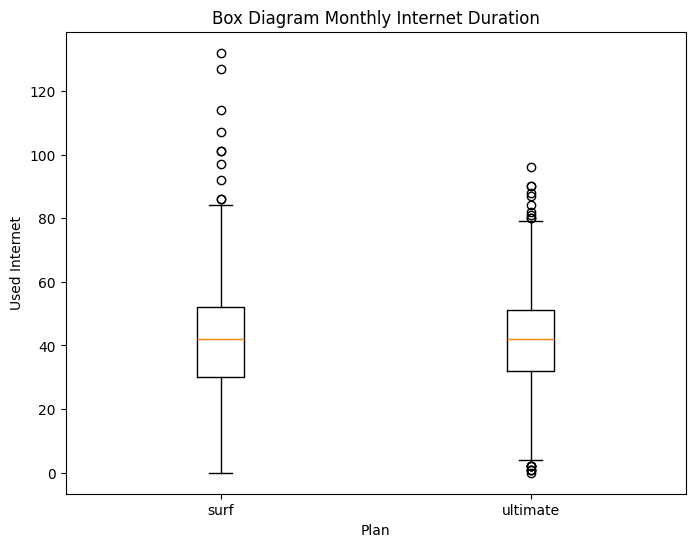

In [47]:
# Create a box plot to visualize the distribution of monthly internet duration
plt.figure(figsize=(8,6))

plt.boxplot([internet_by_month_surf, internet_by_month_ultimate], labels=['surf', 'ultimate'])

plt.title('Box Diagram Monthly Internet Duration')
plt.xlabel('Plan')
plt.ylabel('Used Internet')
plt.show()

- Observing the graphs, we verify that Surf plan users have a limit of 15GB, but their average usage is 40GB, exceeding more than double the limit, generating extra charges. Ultimate plan users have a limit of 30GB, and their average usage is around 41GB, exceeding the limit, but by a smaller margin. Concluding that based on the variance, Surf plan users are more consistent.

<div class="alert alert-success">
<strong>Reviewer's comment v1</strong>

Messages and internet behavior were investigated as requested in the lesson, with graphs and conclusions presented.
</div>

## Revenue

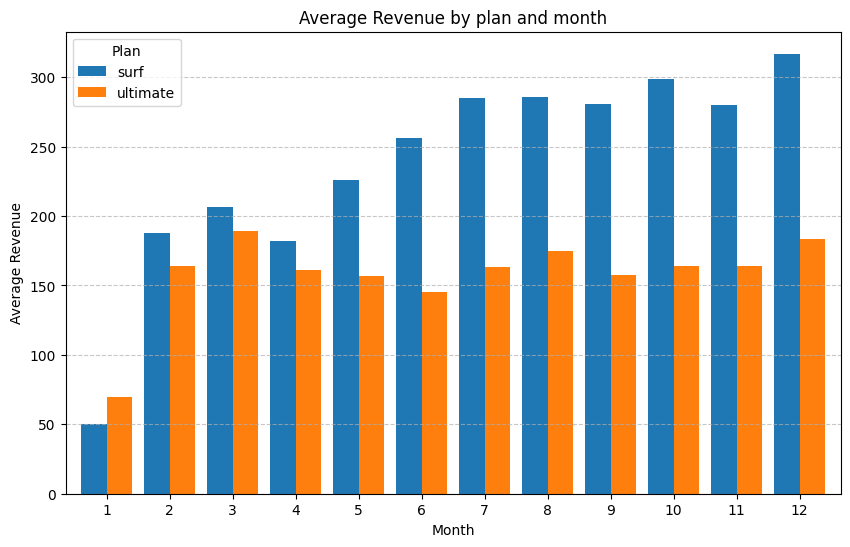

In [48]:
# Compare the average revenue of each plan for each month. Create a bar chart to visualize the result.
overage_calls = df_info_revenue.pivot_table(values='monthly_revenue', index='month', columns='plan', aggfunc='mean')

overage_calls.plot(kind='bar', figsize=(10, 6), width=0.8, rot=0)

plt.title('Average Revenue by plan and month')
plt.xlabel('Month')
plt.ylabel('Average Revenue')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Plan')
plt.show()

In [49]:
# Calculate the mean and variance of monthly revenue
average_var_revenue = df_info_revenue.groupby(['plan'])['monthly_revenue'].agg(['mean', 'var'])
average_var_revenue.columns = ['Average', 'Variance']
print(average_var_revenue)


             Average      Variance
plan                              
surf      282.117724  26647.073083
ultimate  166.629167   7624.603599


/tmp/ipykernel_4015/4248622849.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([surf_revenue, ultimate_revenue], labels=['surf', 'ultimate'])


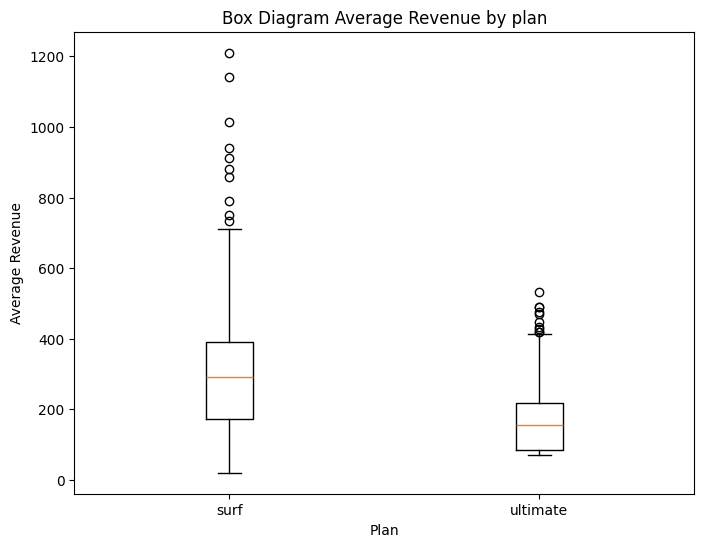

In [50]:
# Create a box plot to visualize the distribution of monthly revenue for each plan
surf_revenue = df_info_revenue[df_info_revenue['plan'] == 'surf']['monthly_revenue']
ultimate_revenue = df_info_revenue[df_info_revenue['plan'] == 'ultimate']['monthly_revenue']


plt.figure(figsize=(8,6))

plt.boxplot([surf_revenue, ultimate_revenue], labels=['surf', 'ultimate'])

plt.title('Box Diagram Average Revenue by plan')
plt.xlabel('Plan')
plt.ylabel('Average Revenue')
plt.show()


- Based on the diagram, the Surf plan generates more average monthly revenue (282.11) than the Ultimate plan (166.62). This suggests that Surf plan users incur more additional charges for exceeding the limits included in the plan, significantly increasing total revenue. The Surf plan also shows the highest variance (26647 vs 7624 for Ultimate), indicating that its revenue is less predictable and varies more among customers. The Ultimate plan's revenue, on the other hand, is more stable and consistent. Considering that the basic monthly fee for Surf is 20 and for Ultimate is 70, the results show that Surf users frequently generate extra charges for exceeding usage of minutes, messages, or internet. In contrast, Ultimate customers tend to stay within their plan limits, resulting in fewer additional charges.

<div class="alert alert-success">
<strong>Reviewer's comment v1</strong>

Revenue was investigated through appropriate graphs and conclusions.

</div>

## Test statistical hypotheses

In [53]:
# Test hypotheses
alpha = 0.05

results = st.ttest_ind(
    surf_revenue,
    ultimate_revenue,
    equal_var=False
)

print('Statistic t:', results.statistic)
print('p-value', results.pvalue)

if results.pvalue < alpha:
    print('We reject the null hypothesis.')
else:
    print('We do not reject the null hypothesis.')


Statistic t: 22.010795080158523
p-value 2.3248333100718407e-97
We reject the null hypothesis.


- Based on the statistical analyses, there is a significant difference between the two means. As the p-value is extremely small, being less than the standard significance level, the probability of this difference having occurred by pure chance is practically zero. This means that the average monthly revenue of Surf plan users is different from the average monthly revenue of Ultimate plan users.

In [55]:
# Test hypotheses
NY_NJ_revenue = df_info_revenue[df_info_revenue['city'].str.contains('NY-NJ', na=False)]['monthly_revenue']
other_regions_revenue = df_info_revenue[~df_info_revenue['city'].str.contains('NY-NJ', na=False)]['monthly_revenue']

alpha = 0.05

results = st.ttest_ind(
    NY_NJ_revenue,
    other_regions_revenue,
    equal_var=False
)

print('Statistic t:', results.statistic)
print('p-value', results.pvalue)

if results.pvalue < alpha:
    print('We reject the null hypothesis.')
else:
    print('We do not reject the null hypothesis.')


Statistic t: 2.8430708284331305
p-value 0.004632562058700096
We reject the null hypothesis.


- Based on the statistical analyses, we cannot affirm that there is a significant difference between the average monthly revenue of users in the NY-NJ region and that of users in other regions. The means are statistically equivalent.

<div class="alert alert-success">
<strong>Reviewer's comment v1</strong>

The tests were correctly formulated, implemented, and analyzed. Very good!
</div>

## General Conclusion


- The objective of this project was to analyze the behavior of 500 Megaline customers to determine which phone plan generates more revenue and to guide the marketing strategy.
   - Data Preparation and Cleaning:
     Data was corrected; dates converted to datetime, call durations rounded up (charged by the full minute), MB converted to GB; `is_active` column created to identify active customers; no critical missing data was found (`NaN` in `churn_date` indicates active customers).
   - User Behavior - Calls: The average minutes used is very similar between plans, ≈428 min (Surf) vs ≈430 min (Ultimate); Call behavior is practically the same between the two plans. Messages: Ultimate users send slightly more messages than Surf users per month. Internet: Surf users average ≈40 GB, exceeding more than double the 15GB limit included in the plan; Ultimate users consume ≈41 GB, exceeding the 30 GB limit, but by a smaller margin. Revenue: The Surf plan generates more average monthly revenue (≈282) than the Ultimate plan (166), due to charges for excess usage; Surf's revenue is more variable (variance ≈26647), while Ultimate's is more stable (≈7624).
   - Hypothesis tests: Surf vs Ultimate: p-value = 0. We reject the null hypothesis. There is a significant difference in revenue between the plans; NY-NJ vs other regions: p-value = 0.004. We reject the null hypothesis. There is a significant difference in revenue by region.
- Based on 500 Megaline customers throughout 2018, it is concluded that the Surf plan generates more total revenue for the company, while the Ultimate plan presents a more stable and higher average revenue per user, although with a lower total volume due to the smaller number of subscribers in the sample.
- As a recommendation, the commercial department should direct most of its advertising budget towards acquiring new customers for the Surf plan.